In [43]:
import pandas as pd

In [44]:
stressLvlDf = pd.read_csv("../data/raw/StressLevelDataset.csv")

In [45]:
stressLvlDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [46]:
stressLvlDf.head(10)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1
5,20,13,1,21,3,3,1,4,3,2,...,1,2,5,2,5,1,4,4,5,2
6,4,26,0,6,1,2,4,1,1,4,...,4,5,1,4,1,3,2,2,1,0
7,17,3,1,22,4,3,1,5,3,1,...,1,1,3,2,4,1,4,4,5,2
8,13,22,1,12,3,1,2,4,3,3,...,3,3,3,2,3,3,3,2,2,1
9,6,8,0,27,4,3,1,2,0,5,...,2,2,2,1,5,1,5,3,4,1


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [48]:
#Scaling Dataset using standerd scaler

#Except
#Binary coulmn  mental_health_history

In [49]:
#Splitting

target_col = "stress_level"
X = stressLvlDf.drop(columns=[target_col])
y = stressLvlDf[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [50]:
numeric_cols = [c for c in X.columns if c not in ["mental_health_history"]]

preprocessor = ColumnTransformer(transformers=[("scale_numeric", StandardScaler(), numeric_cols)], remainder="passthrough")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train[numeric_cols].describe())

       anxiety_level  self_esteem  depression    headache  blood_pressure  \
count     880.000000   880.000000  880.000000  880.000000      880.000000   
mean       11.051136    17.892045   12.570455    2.488636        2.187500   
std         6.201646     8.936557    7.715477    1.398799        0.830356   
min         0.000000     0.000000    0.000000    0.000000        1.000000   
25%         6.000000    11.000000    7.000000    1.000000        1.000000   
50%        11.000000    19.500000   12.000000    2.500000        2.000000   
75%        17.000000    26.000000   19.000000    3.000000        3.000000   
max        21.000000    30.000000   27.000000    5.000000        3.000000   

       sleep_quality  breathing_problem  noise_level  living_conditions  \
count     880.000000         880.000000   880.000000         880.000000   
mean        2.659091           2.728409     2.651136           2.519318   
std         1.544828           1.398069     1.332152           1.124589   
min   

In [51]:
print(X_train.columns.tolist())

['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']


In [52]:
#adding target

In [53]:
train_df = pd.DataFrame(X_train_processed, columns=numeric_cols + ["mental_health_history"])[X.columns]
test_df = pd.DataFrame(X_test_processed, columns=numeric_cols + ["mental_health_history"])[X.columns]

train_df["target"] = y_train.values
test_df["target"] = y_test.values

#to keep mental health history as 1,2,0
train_df["mental_health_history"] = train_df["mental_health_history"].astype(int)
test_df["mental_health_history"] = test_df["mental_health_history"].astype(int)

In [54]:
train_df.to_csv("../results/outputs/Splits Stress_level_dataset/stress_level_train_scaled.csv", index=False)
test_df.to_csv("../results/outputs//Splits Stress_level_dataset/stress_level_test_scaled.csv", index=False)

full_processed_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

full_processed_df["mental_health_history"] = full_processed_df["mental_health_history"].astype(int)

full_processed_df.to_csv("../results/outputs/stress_dataset_scaled_full_Stress_Level_dataset.csv", index=False)
print("Saved", full_processed_df.shape)
print("Saved train:", train_df.shape)
print("Saved test:", test_df.shape)

Saved (1100, 21)
Saved train: (880, 21)
Saved test: (220, 21)


In [55]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 880 non-null    float64
 1   self_esteem                   880 non-null    float64
 2   mental_health_history         880 non-null    int64  
 3   depression                    880 non-null    float64
 4   headache                      880 non-null    float64
 5   blood_pressure                880 non-null    float64
 6   sleep_quality                 880 non-null    float64
 7   breathing_problem             880 non-null    float64
 8   noise_level                   880 non-null    float64
 9   living_conditions             880 non-null    float64
 10  safety                        880 non-null    float64
 11  basic_needs                   880 non-null    float64
 12  academic_performance          880 non-null    float64
 13  study

In [56]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 220 non-null    float64
 1   self_esteem                   220 non-null    float64
 2   mental_health_history         220 non-null    int64  
 3   depression                    220 non-null    float64
 4   headache                      220 non-null    float64
 5   blood_pressure                220 non-null    float64
 6   sleep_quality                 220 non-null    float64
 7   breathing_problem             220 non-null    float64
 8   noise_level                   220 non-null    float64
 9   living_conditions             220 non-null    float64
 10  safety                        220 non-null    float64
 11  basic_needs                   220 non-null    float64
 12  academic_performance          220 non-null    float64
 13  study

In [57]:
scaledStressData = pd.read_csv("../results/outputs/stress_dataset_scaled_full_Stress_Level_dataset.csv")

In [58]:
scaledStressData.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,target
0,0.314428,0.795832,1,-0.333345,-0.349524,-1.430923,-0.426886,-0.521307,-0.489063,-0.462047,...,0.147712,0.152196,-0.453969,0.239311,-0.416290,0.118375,0.187084,0.163779,-0.413484,1
1,1.282463,-0.771658,1,1.611905,1.081086,0.979053,-1.074576,1.625730,1.764213,-1.351767,...,-0.540048,-1.265078,1.067908,-0.479438,0.887394,-0.837312,1.594209,1.563055,1.549820,2
2,-1.621643,0.795832,0,-1.241128,-1.064830,-0.225935,1.516182,-1.236986,-1.240155,1.317391,...,0.835473,0.860833,-1.214908,0.958060,-1.068132,1.074062,-1.220041,-0.535859,-1.067918,0
3,0.637107,-0.883621,1,0.574438,1.081086,0.979053,-1.074576,1.625730,1.764213,-1.351767,...,-0.540048,-1.265078,1.828847,-1.198188,0.887394,-0.837312,1.594209,0.863417,1.549820,2
4,-0.653607,1.019759,0,-1.630178,-1.064830,-0.225935,0.868493,-0.521307,-0.489063,0.427672,...,0.835473,0.860833,-1.214908,0.958060,-1.068132,1.074062,-0.516479,-1.235497,-1.067918,0


In [59]:
#Checking balance

In [60]:
print(scaledStressData["target"].value_counts())

target
0    373
2    369
1    358
Name: count, dtype: int64


In [61]:
#Dataset is balanced

In [62]:
#Saving scaler

import joblib
joblib.dump(preprocessor, "../results/model_trained_files/preprocessor.pkl")

['../results/model_trained_files/preprocessor.pkl']

In [63]:
#EDA

In [64]:
import matplotlib.pyplot as plt

In [65]:
#Before Scaling

                              min  max
self_esteem                     0   30
depression                      0   27
anxiety_level                   0   21
extracurricular_activities      0    5
peer_pressure                   0    5
future_career_concerns          0    5
teacher_student_relationship    0    5
study_load                      0    5
academic_performance            0    5
basic_needs                     0    5
safety                          0    5
living_conditions               0    5
noise_level                     0    5
breathing_problem               0    5
sleep_quality                   0    5
headache                        0    5
bullying                        0    5
blood_pressure                  1    3
social_support                  0    3
mental_health_history           0    1


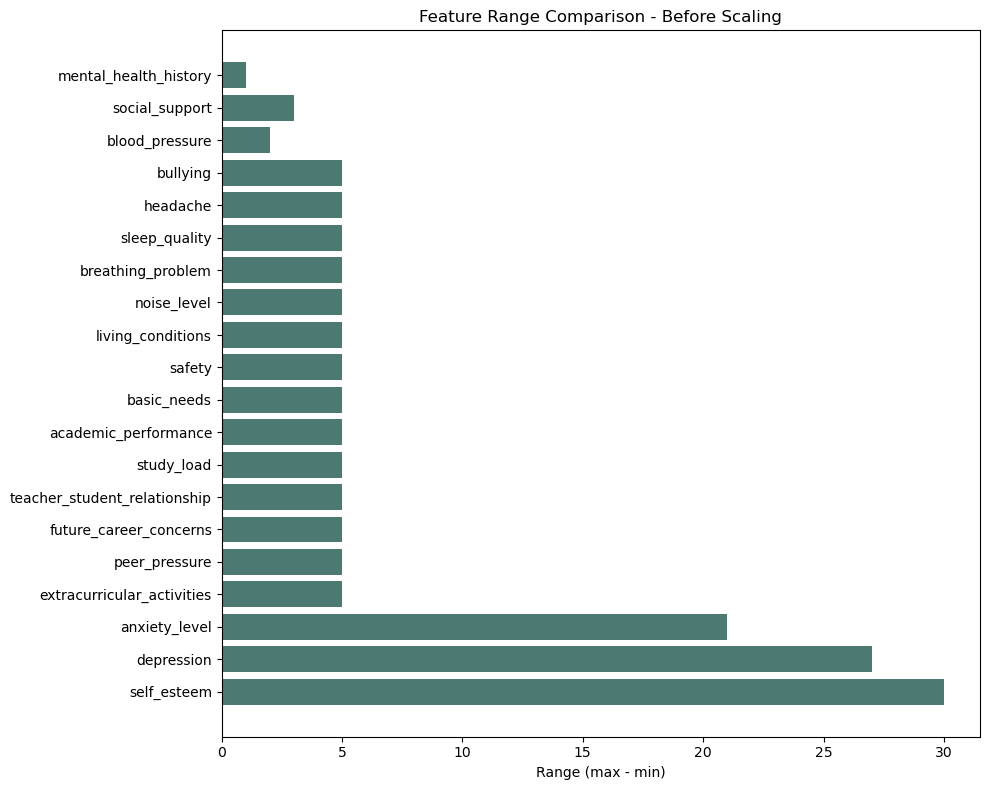

In [66]:
feature_cols = [c for c in stressLvlDf.columns if c != "stress_level"]

ranges = pd.DataFrame({
    "min": stressLvlDf[feature_cols].min(),
    "max": stressLvlDf[feature_cols].max()
}).sort_values("max", ascending=False)

print(ranges)

plt.figure(figsize=(10, 8))
plt.barh(ranges.index, ranges["max"] - ranges["min"], color='#4C7A73')
plt.xlabel("Range (max - min)")
plt.title("Feature Range Comparison - Before Scaling")
plt.tight_layout()
plt.show()

In [67]:
#After Scaling

                                   min       max
living_conditions            -2.241486  2.207111
depression                   -1.630178  1.871271
study_load                   -1.975846  1.828847
headache                     -1.780135  1.796392
noise_level                  -1.991247  1.764213
teacher_student_relationship -1.916937  1.676809
breathing_problem            -1.952666  1.625730
safety                       -1.940134  1.610860
anxiety_level                -1.782982  1.605142
peer_pressure                -1.923604  1.594209
academic_performance         -1.973715  1.569470
extracurricular_activities   -1.935135  1.563055
bullying                     -1.722353  1.549820
future_career_concerns       -1.719974  1.539236
basic_needs                  -1.915569  1.523233
sleep_quality                -1.722265  1.516182
self_esteem                  -2.003257  1.355650
social_support               -1.792999  1.074062
mental_health_history         0.000000  1.000000
blood_pressure      

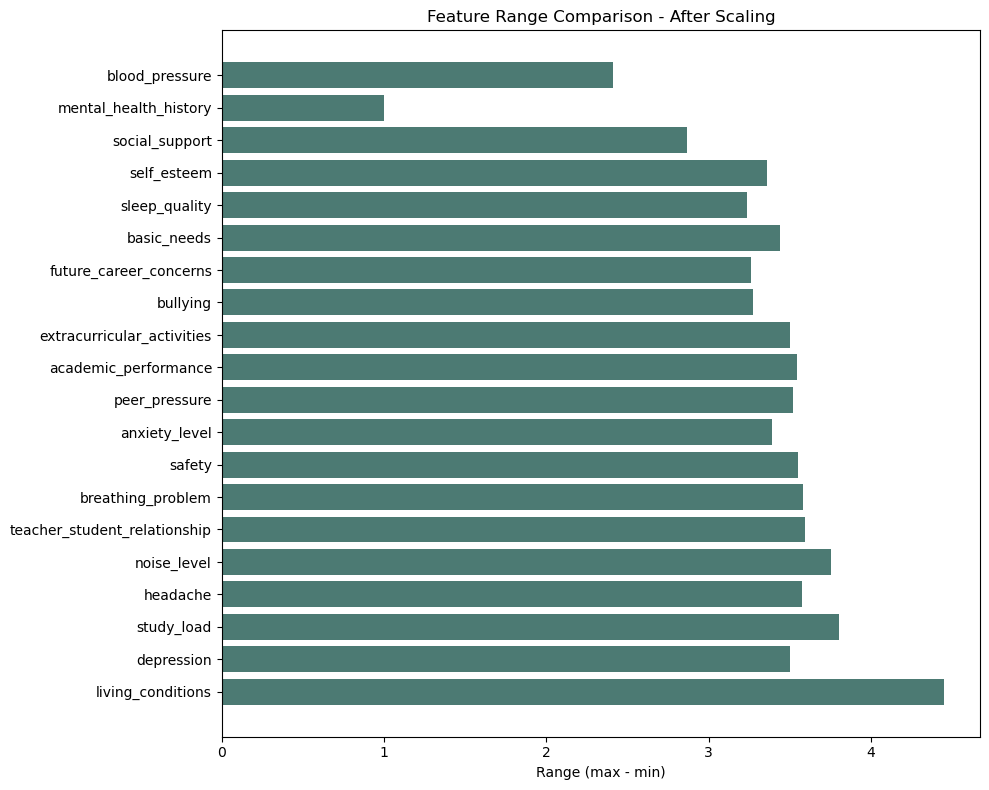

In [68]:
feature_cols = [c for c in scaledStressData.columns if c != "target"]

ranges = pd.DataFrame({
    "min": scaledStressData[feature_cols].min(),
    "max": scaledStressData[feature_cols].max()
}).sort_values("max", ascending=False)

print(ranges)

plt.figure(figsize=(10, 8))
plt.barh(ranges.index, ranges["max"] - ranges["min"], color='#4C7A73')
plt.xlabel("Range (max - min)")
plt.title("Feature Range Comparison - After Scaling")
plt.tight_layout()
plt.show()

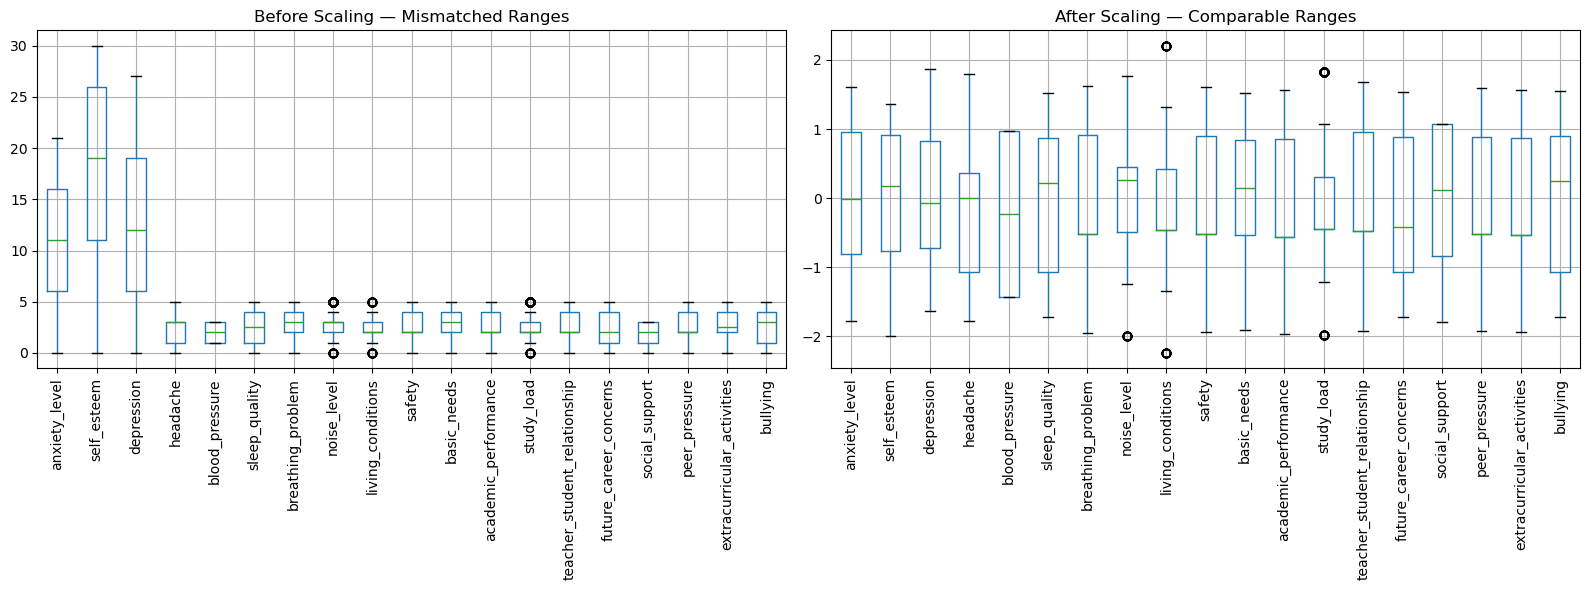

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

stressLvlDf[numeric_cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title("Before Scaling — Mismatched Ranges")

train_df[numeric_cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title("After Scaling — Comparable Ranges")

plt.tight_layout()
plt.show()

In [70]:
#data balancing perfectly

In [71]:
print(scaledStressData["target"].value_counts())

target
0    373
2    369
1    358
Name: count, dtype: int64


In [72]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [73]:
print("Before SMOTE:", y_train.value_counts())

Before SMOTE: stress_level
0    299
2    295
1    286
Name: count, dtype: int64


In [74]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [75]:
print("After SMOTE:", y_train_balanced.value_counts())

After SMOTE: stress_level
1    299
2    299
0    299
Name: count, dtype: int64


In [76]:
#Now dataset is fully balanced

In [77]:
train_balanced = X_train_balanced.copy()
train_balanced['target'] = y_train_balanced

#train_balanced.to_csv("../results/outputs/Splits Stress_level_dataset/stress_level_train_scaled.csv", index=False)

In [78]:
train_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 897 entries, 0 to 896
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 897 non-null    int64
 1   self_esteem                   897 non-null    int64
 2   mental_health_history         897 non-null    int64
 3   depression                    897 non-null    int64
 4   headache                      897 non-null    int64
 5   blood_pressure                897 non-null    int64
 6   sleep_quality                 897 non-null    int64
 7   breathing_problem             897 non-null    int64
 8   noise_level                   897 non-null    int64
 9   living_conditions             897 non-null    int64
 10  safety                        897 non-null    int64
 11  basic_needs                   897 non-null    int64
 12  academic_performance          897 non-null    int64
 13  study_load                    897 n

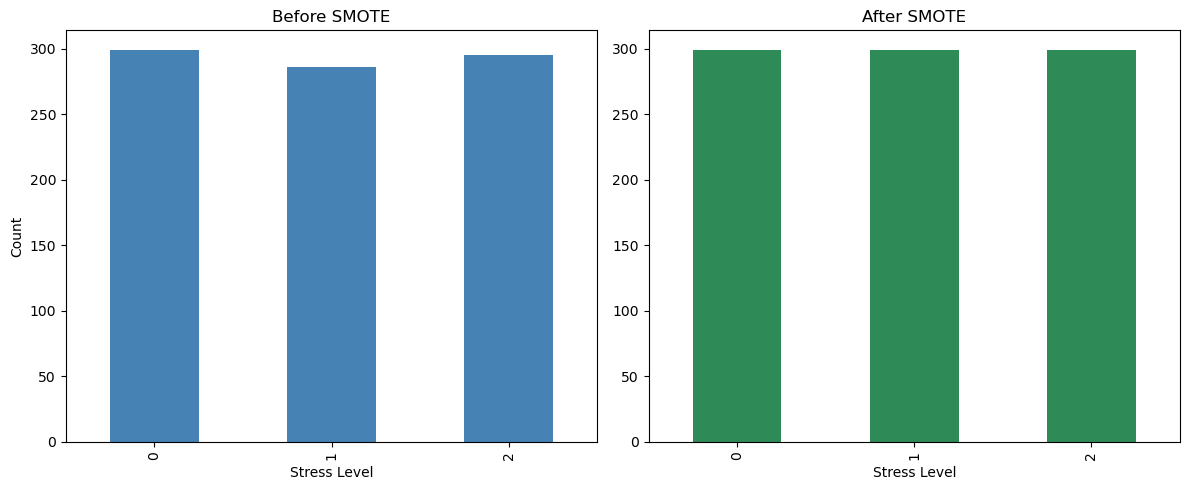

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("Count")

y_train_balanced.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Stress Level")

plt.tight_layout()
plt.savefig("../results/eda_visualizations/class_balance_comparison.png", dpi=150)
plt.show()

In [80]:
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

In [81]:
#visualizing pca balance after SMOTE

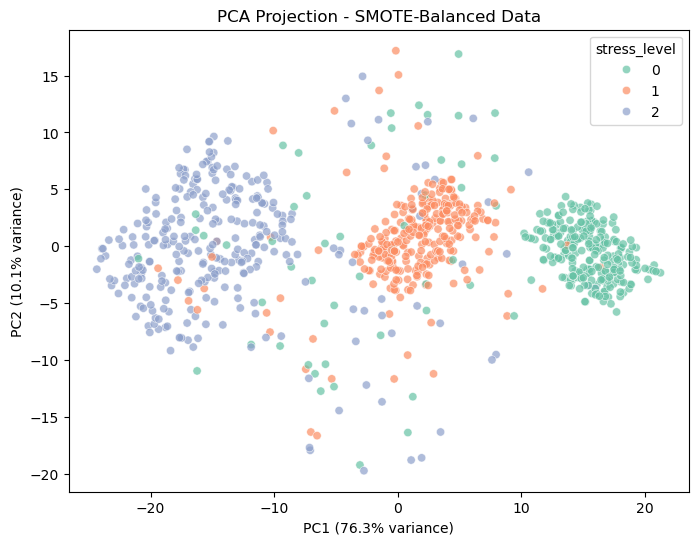

In [82]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_balanced)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train_balanced, palette='Set2', alpha=0.7)
plt.title("PCA Projection - SMOTE-Balanced Data")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.savefig("../results/eda_visualizations/pca_smote.png", dpi=150)

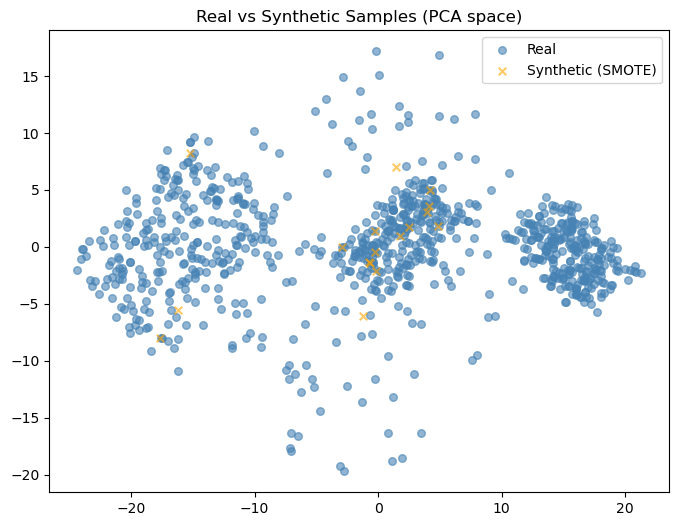

In [83]:
n_real = len(X_train)
n_synthetic = len(X_train_balanced) - n_real

X_pca_all = pca.fit_transform(X_train_balanced)

is_synthetic = np.array([False] * n_real + [True] * n_synthetic)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_all[~is_synthetic, 0], X_pca_all[~is_synthetic, 1], 
            c='steelblue', label='Real', alpha=0.6, s=30)
plt.scatter(X_pca_all[is_synthetic, 0], X_pca_all[is_synthetic, 1], 
            c='orange', label='Synthetic (SMOTE)', alpha=0.6, s=30, marker='x')
plt.legend()
plt.title("Real vs Synthetic Samples (PCA space)")
plt.savefig("../results/eda_visualizations/real_vs_synthetic_scatter.png", dpi=150)
plt.show()

In [84]:
train_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 897 entries, 0 to 896
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 897 non-null    int64
 1   self_esteem                   897 non-null    int64
 2   mental_health_history         897 non-null    int64
 3   depression                    897 non-null    int64
 4   headache                      897 non-null    int64
 5   blood_pressure                897 non-null    int64
 6   sleep_quality                 897 non-null    int64
 7   breathing_problem             897 non-null    int64
 8   noise_level                   897 non-null    int64
 9   living_conditions             897 non-null    int64
 10  safety                        897 non-null    int64
 11  basic_needs                   897 non-null    int64
 12  academic_performance          897 non-null    int64
 13  study_load                    897 n